# 📊 Trader Performance vs Bitcoin Market Sentiment
### An End-to-End Machine Learning Pipeline

---

**Internship Assignment | Hyperliquid Historical Trade Analysis**

In this notebook, we will build a complete, production-style machine learning pipeline from raw data all the way to a trained XGBoost classifier. Our goal is to predict whether a given trade will be profitable (Closed PnL > 0) by combining historical trade records from Hyperliquid with daily Bitcoin Fear & Greed sentiment scores.

We will follow a clean, step-by-step structure:

1. **Load Data** — Import both CSV files and inspect them
2. **Preliminary Checks** — Shape, data types, variance, standard deviation, and first 5 rows
3. **Handle Missing Values** — Identify and remove nulls systematically
4. **Exploratory Data Analysis (EDA)** — Visualize every meaningful relationship in the data
5. **Outlier Removal** — Detect and clip absurd outliers using the IQR / percentile method
6. **Feature Engineering & Encoding** — Prepare the data for modeling
7. **Model Training** — Train an XGBoost classifier with a proper 60/20/20 time-based split
8. **Model Evaluation** — Evaluate on validation and test sets; tune the decision threshold

> **Note:** We are using a **time-based split** (not random split) because trading data is sequential. Using a random split would cause data leakage — the model would accidentally learn from the future.

---

In [6]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 4.7 MB/s  0:00:00m 4.9 MB/s eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 1 — Import Libraries

Before we do anything, we import all the libraries we will need throughout this notebook. Think of this as setting up your lab before running any experiments. We are importing:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for visualization
- `xgboost` for our gradient boosting classifier
- `sklearn` for model evaluation metrics
- `warnings` to keep our output clean

---

## Step 2 — Load the Datasets

We have two datasets:

1. **`historical_data.csv`** — Contains every trade executed on Hyperliquid. Each row is a single trade with information like which coin was traded, the execution price, trade size in USD, whether it was a BUY or SELL, and the final Closed PnL.
2. **`fear_greed_index.csv`** — Contains the daily Bitcoin Fear & Greed Index. This index assigns a score from 0 to 100 and a label (Extreme Fear, Fear, Neutral, Greed, Extreme Greed) to each calendar day based on market sentiment signals.

Loading them separately first allows us to inspect each one independently before we merge them.

In [9]:
trades = pd.read_csv("input/historical_data.csv")
sentiment = pd.read_csv("input/fear_greed_index.csv")

print("Trade data loaded:", trades.shape)
print("Sentiment data loaded:", sentiment.shape)

Trade data loaded: (211224, 16)
Sentiment data loaded: (2644, 4)


---

## Step 3 — Preliminary Checks

Before touching any data, a good data scientist always pauses to understand what they are working with. This is the equivalent of reading the ingredients label before you start cooking.

We will check:
- **Shape** — How many rows and columns do we have?
- **Column names** — What features are available?
- **Data types** — Are dates stored as strings? Are numbers stored as objects?
- **First 5 rows** — What does the raw data actually look like?

This step almost always reveals surprises.

In [10]:
print("=== TRADES DATASET ===")
print("Shape:", trades.shape)
print("\nColumn Names:")
print(trades.columns.tolist())

=== TRADES DATASET ===
Shape: (211224, 16)

Column Names:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [11]:
print("=== SENTIMENT DATASET ===")
print("Shape:", sentiment.shape)
print("\nColumn Names:")
print(sentiment.columns.tolist())

=== SENTIMENT DATASET ===
Shape: (2644, 4)

Column Names:
['timestamp', 'value', 'classification', 'date']


In [12]:
print("First 5 rows of Trades:")
trades.head()

First 5 rows of Trades:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [13]:
print("First 5 rows of Sentiment:")
sentiment.head()

First 5 rows of Sentiment:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### 3.1 — Data Types and Memory Info

Now let's look at the data types of each column. This is important because machine learning models can only work with numbers. Any column that should be numeric but is stored as `object` (string) will need to be fixed. We will also see the memory usage of our dataframe, which helps us plan for large datasets.

In [14]:
print("Data Types and Memory Info for Trades:")
trades.info()

Data Types and Memory Info for Trades:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-

In [15]:
print("Data Types and Memory Info for Sentiment:")
sentiment.info()

Data Types and Memory Info for Sentiment:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


### 3.2 — Variance and Standard Deviation

Variance and standard deviation tell us how **spread out** the values in each numeric column are.

- A **high variance** in a feature like `Closed PnL` means there are very big wins and very big losses. This is expected in trading data.
- A **near-zero variance** in a feature means that column barely changes and will likely provide no useful signal to our model — we can consider dropping it.
- **Standard deviation** is just the square root of variance, expressed in the same units as the original data, making it easier to interpret.

Looking at these statistics together with the mean gives us a full picture of the distribution before we even plot anything.

In [16]:
numeric_cols = trades.select_dtypes(include=[np.number]).columns.tolist()

print("Variance of Numeric Columns in Trades:")
print(trades[numeric_cols].var().round(4))

Variance of Numeric Columns in Trades:
Execution Price    8.671644e+08
Size Tokens        1.087284e+10
Size USD           1.337741e+09
Start Position     4.540164e+11
Closed PnL         8.448640e+05
Order ID           3.369987e+20
Fee                4.568210e+01
Trade ID           1.061173e+29
Timestamp          7.551471e+19
dtype: float64


In [17]:
print("Standard Deviation of Numeric Columns in Trades:")
print(trades[numeric_cols].std().round(4))

Standard Deviation of Numeric Columns in Trades:
Execution Price    2.944765e+04
Size Tokens        1.042729e+05
Size USD           3.657514e+04
Start Position     6.738074e+05
Closed PnL         9.191648e+02
Order ID           1.835753e+10
Fee                6.758900e+00
Trade ID           3.257565e+14
Timestamp          8.689920e+09
dtype: float64


In [18]:
print("Full Descriptive Statistics of Trades:")
trades[numeric_cols].describe().T

Full Descriptive Statistics of Trades:


,count,mean,std,min,25%,50%,75%,max
Execution Price,211224.0,1.141472e+04,2.944765e+04,4.530000e-06,4.854700e+00,1.828000e+01,1.015800e+02,1.090040e+05
Size Tokens,211224.0,4.623365e+03,1.042729e+05,8.740000e-07,2.940000e+00,3.200000e+01,1.879025e+02,1.582244e+07
Size USD,211224.0,5.639451e+03,3.657514e+04,0.000000e+00,1.937900e+02,5.970450e+02,2.058960e+03,3.921431e+06
Start Position,211224.0,-2.994625e+04,6.738074e+05,-1.433463e+07,-3.762311e+02,8.472793e+01,9.337278e+03,3.050948e+07
Closed PnL,211224.0,4.874900e+01,9.191648e+02,-1.179901e+05,0.000000e+00,0.000000e+00,5.792797e+00,1.353291e+05
Order ID,211224.0,6.965388e+10,1.835753e+10,1.732711e+08,5.983853e+10,7.442939e+10,8.335543e+10,9.014923e+10
Fee,211224.0,1.163967e+00,6.758854e+00,-1.175712e+00,1.612094e-02,8.957750e-02,3.938110e-01,8.374716e+02
Trade ID,211224.0,5.628549e+14,3.257565e+14,0.000000e+00,2.810000e+14,5.620000e+14,8.460000e+14,1.130000e+15
Timestamp,211224.0,1.737744e+12,8.689920e+09,1.680000e+12,1.740000e+12,1.740000e+12,1.740000e+12,1.750000e+12


---

## Step 4 — Handle Missing Values

Missing values are one of the most common problems in real-world data. If we feed a model rows that contain `NaN` (Not a Number), most algorithms will either crash or silently produce wrong results.

Our approach is straightforward:
1. First, **count** how many missing values exist in each column.
2. Then, **remove** rows where any critical column is missing.

We are removing rows rather than imputing (filling in) values because in trading data, a missing timestamp, price, or sentiment classification cannot be meaningfully guessed. Imputing fake trade data would distort our analysis.

In [19]:
print("Missing values in Trades dataset:")
print(trades.isnull().sum())

Missing values in Trades dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [20]:
print("Missing values in Sentiment dataset:")
print(sentiment.isnull().sum())

Missing values in Sentiment dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64


### 4.1 — Merge the Two Datasets

Now we join the two datasets on the **date column**. The idea is simple: for every trade that happened on, say, January 15th, we want to attach what the market sentiment was on that same day.

We use a `left join` so that every trade record is kept, even if there happens to be no sentiment data for that date. Those rows will show `NaN` for sentiment columns after the merge, and we will remove them in the next step.

Before merging, we must convert both date columns to the same format (`datetime.date`), otherwise the join will silently fail and produce no matches.

In [21]:
trades["trade_datetime"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
trades["date"] = trades["trade_datetime"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

print("Date columns prepared.")
print("Sample trade date:", trades["date"].iloc[0])
print("Sample sentiment date:", sentiment["date"].iloc[0])

Date columns prepared.
Sample trade date: 2024-12-02
Sample sentiment date: 2018-02-01


In [22]:
merged = trades.merge(sentiment, on="date", how="left")

print("Merged dataset shape:", merged.shape)
print("Rows with missing sentiment after merge:", merged["classification"].isnull().sum())

Merged dataset shape: (211224, 21)
Rows with missing sentiment after merge: 6


### 4.2 — Remove Invalid and Missing Rows

Now we apply a set of hard data quality rules. We want to remove any row where:
- Core columns like `timestamp`, `value`, or `classification` are missing
- Execution price, size, or fee have physically impossible values (zero or negative)
- The trade `Side` is not BUY or SELL (e.g., internal system events)
- The sentiment score is outside the valid range of 0 to 100
- The row is a `Spot Dust Conversion` which is not a real trade
- The row is a duplicate

We define each rule as a boolean mask. Any row that violates even one rule gets removed.

In [23]:
df = merged.dropna(subset=["timestamp", "value", "classification"]).copy()
print("Rows after dropping missing critical columns:", df.shape[0])

Rows after dropping missing critical columns: 211218


In [24]:
rules = {
    "missing_any": df.isnull().any(axis=1),
    "duplicate_row": df.duplicated(),
    "bad_execution_price": df["Execution Price"] <= 0,
    "bad_size_tokens": df["Size Tokens"] <= 0,
    "bad_size_usd": df["Size USD"] <= 0,
    "bad_sentiment_value": ~df["value"].between(0, 100),
    "bad_side": ~df["Side"].isin(["BUY", "SELL"]),
    "bad_classification": ~df["classification"].isin(
        ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
    ),
    "dust_conversion": df["Direction"].eq("Spot Dust Conversion"),
    "missing_closed_pnl": df["Closed PnL"].isnull(),
}

print("Rule violation counts:")
for rule, mask in rules.items():
    print(f"  {rule}: {mask.sum()} rows")

Rule violation counts:
  missing_any: 0 rows
  duplicate_row: 0 rows
  bad_execution_price: 0 rows
  bad_size_tokens: 0 rows
  bad_size_usd: 43 rows
  bad_sentiment_value: 0 rows
  bad_side: 0 rows
  bad_classification: 0 rows
  dust_conversion: 142 rows
  missing_closed_pnl: 0 rows


In [25]:
invalid_mask = (
    df.isnull().any(axis=1) |
    df.duplicated() |
    (df["Execution Price"] <= 0) |
    (df["Size Tokens"] <= 0) |
    (df["Size USD"] <= 0) |
    (~df["value"].between(0, 100)) |
    (~df["Side"].isin(["BUY", "SELL"])) |
    (~df["classification"].isin(["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"])) |
    (df["Direction"] == "Spot Dust Conversion") |
    (df["Closed PnL"].isnull())
)

df_clean = df[~invalid_mask].copy()

print(f"Before cleaning: {df.shape[0]} rows")
print(f"After cleaning:  {df_clean.shape[0]} rows")
print(f"Rows removed:    {df.shape[0] - df_clean.shape[0]} rows")

Before cleaning: 211218 rows
After cleaning:  211076 rows
Rows removed:    142 rows


In [26]:
print("Final check — any remaining violations?")
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

Final check — any remaining violations?
Missing values: 0
Duplicates: 0


---

## Step 5 — Exploratory Data Analysis (EDA)

Now comes one of the most important parts of any machine learning project: **understanding your data visually**.

EDA helps us answer questions like:
- Does market sentiment actually affect profitability?
- Do BUY and SELL trades behave differently under different market conditions?
- Which coins are most profitable?
- How are trades distributed across sentiment categories?

The answers to these questions will inform our feature engineering decisions later. If sentiment has no visible relationship with PnL here, we should not expect our model to find one either. Always look at your data before you model it.

In [27]:
df_clean["win"] = df_clean["Closed PnL"] > 0

sentiment_summary = df_clean.groupby("classification").agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    win_rate=("win", "mean"),
    trade_count=("Closed PnL", "count"),
    avg_size_usd=("Size USD", "mean")
).reset_index()

print("Sentiment Summary Table:")
sentiment_summary

Sentiment Summary Table:


,classification,total_pnl,avg_pnl,win_rate,trade_count,avg_size_usd
0,Extreme Fear,7.391102e+05,34.542705,0.370659,21397,5350.481878
1,Extreme Greed,2.715171e+06,67.947230,0.465315,39960,3114.743825
2,Fear,3.357155e+06,54.327299,0.421053,61795,7821.422088
3,Greed,2.150129e+06,42.790345,0.385249,50248,5743.163655
4,Neutral,1.292921e+06,34.316824,0.397096,37676,4784.001985


### 5.1 — Total PnL by Sentiment Category

This chart answers the first key question: **Which sentiment condition generates the most total profit?**

If traders make more money during Greed phases, it suggests that a bullish market sentiment creates favorable conditions for profitable trades. If Fear phases show negative PnL, it means traders tend to lose money when the market is fearful — possibly because they panic-trade or hold losing positions too long.

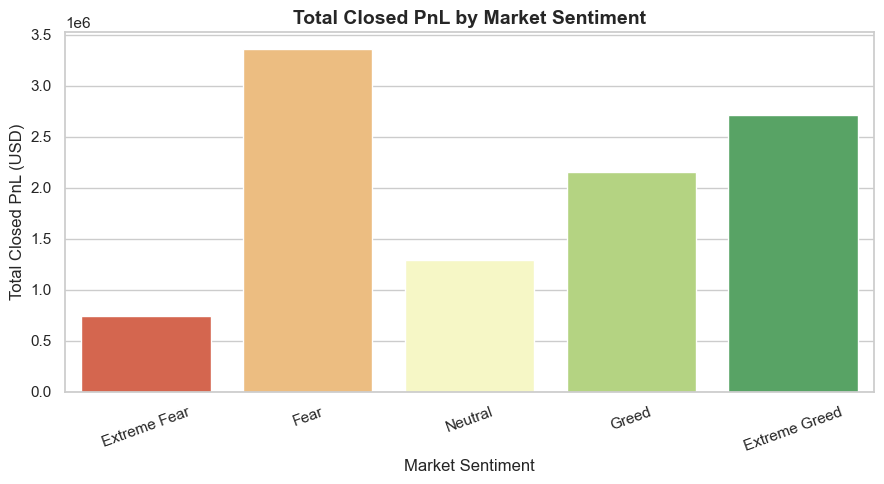

In [28]:
sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="total_pnl",
    order=sentiment_order,
    palette="RdYlGn"
)
plt.title("Total Closed PnL by Market Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.2 — Win Rate by Sentiment Category

Total PnL can be misleading. A single huge winning trade in one category can dominate the bar chart. **Win rate** is a more robust measure because it asks: "What fraction of trades were profitable?" regardless of size.

A high win rate in a specific sentiment condition gives us more confidence that success there is systematic, not driven by outlier trades.

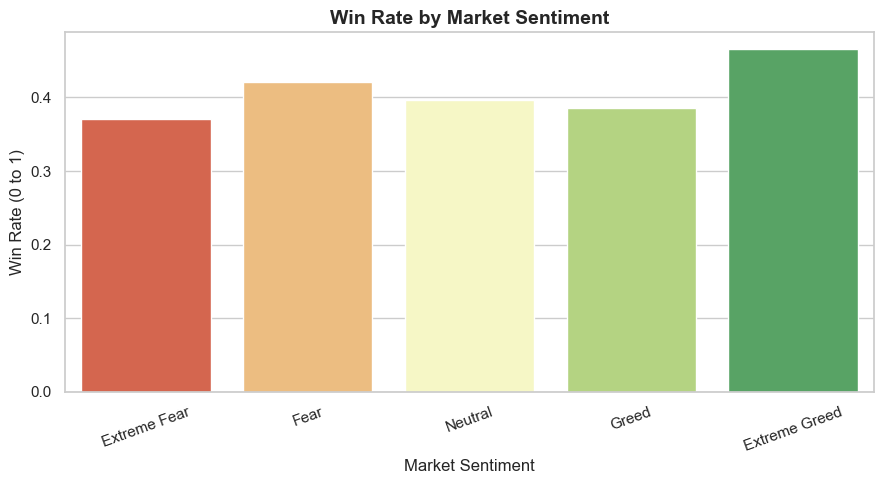

In [29]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="win_rate",
    order=sentiment_order,
    palette="RdYlGn"
)
plt.title("Win Rate by Market Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (0 to 1)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.3 — Average PnL per Trade by Sentiment

Average PnL per trade normalizes for the number of trades in each category. This tells us: **when I place a trade during this sentiment condition, how much do I expect to make or lose on average?**

A sentiment category with many low-value trades might look great on total PnL but be mediocre on average. This chart helps us identify the truly high-quality trading environments.

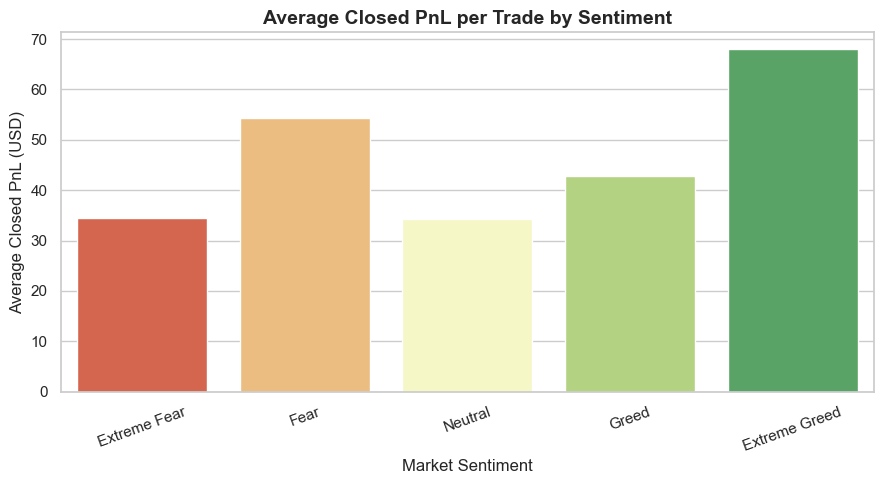

In [30]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="avg_pnl",
    order=sentiment_order,
    palette="RdYlGn"
)
plt.title("Average Closed PnL per Trade by Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.4 — Number of Trades by Sentiment

It is important to understand **how many trades** exist in each sentiment category. A bar with 50 trades is very different from a bar with 5,000 trades — even if the average PnL looks the same. Categories with very few trades may not be statistically reliable.

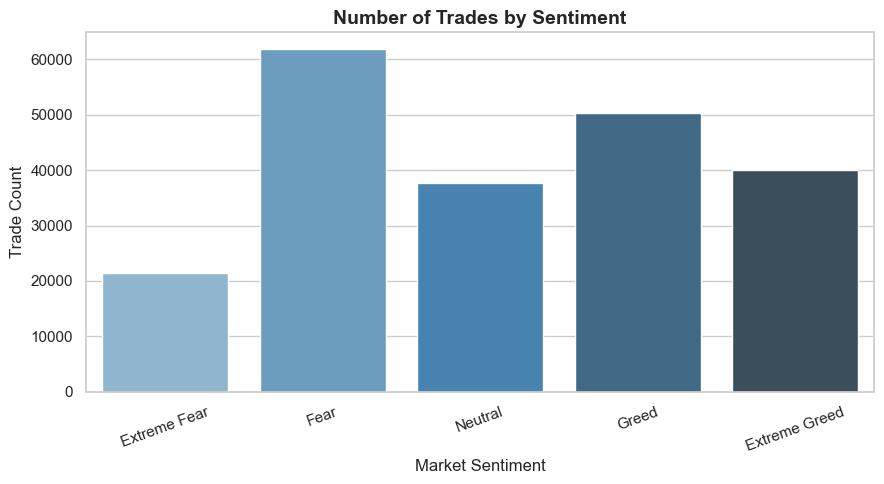

In [31]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=sentiment_summary,
    x="classification",
    y="trade_count",
    order=sentiment_order,
    palette="Blues_d"
)
plt.title("Number of Trades by Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.5 — Distribution of Closed PnL

Before we go further, let's look at the **shape of our target variable distribution**. The histogram will show us whether PnL is roughly normally distributed, or heavily skewed. In trading data, we typically expect a left skew (many small losses and a few large wins, or vice versa). Understanding this helps us choose the right model and evaluation metrics.

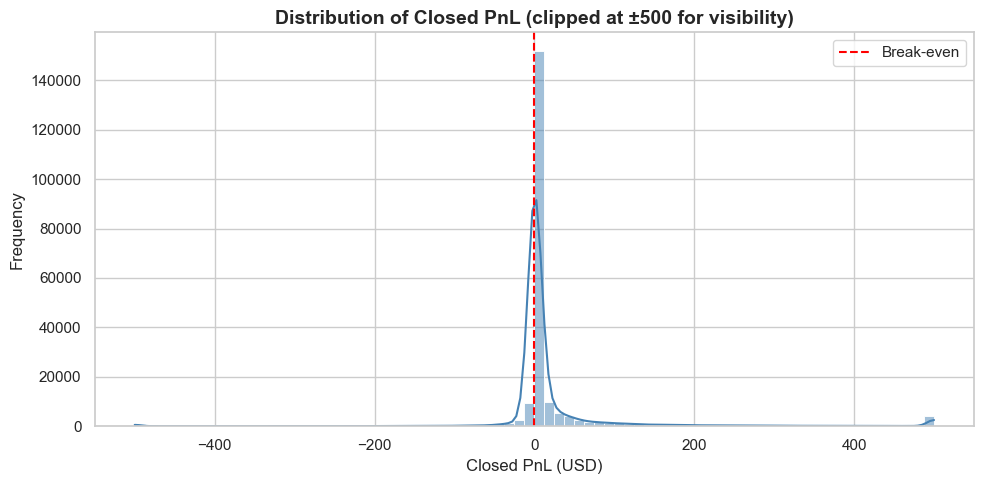

In [32]:
plt.figure(figsize=(10, 5))
clipped_pnl = df_clean["Closed PnL"].clip(-500, 500)
sns.histplot(clipped_pnl, bins=80, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Break-even")
plt.title("Distribution of Closed PnL (clipped at ±500 for visibility)", fontsize=14, fontweight="bold")
plt.xlabel("Closed PnL (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 5.6 — BUY vs SELL Total PnL by Sentiment

We now break down performance by **trade direction** (BUY vs SELL) across each sentiment category. This is a critical insight for any trading strategy.

It is entirely possible — and common — that SELL trades perform much better during Extreme Fear while BUY trades shine during Extreme Greed. If we find such patterns, we can use sentiment as a directional filter: only BUY during Greed conditions, only SELL during Fear conditions.

In [33]:
side_summary = df_clean.groupby(["classification", "Side"]).agg(
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    win_rate=("win", "mean"),
    trade_count=("Closed PnL", "count")
).reset_index()

print("BUY vs SELL Breakdown by Sentiment:")
side_summary

BUY vs SELL Breakdown by Sentiment:


,classification,Side,total_pnl,avg_pnl,win_rate,trade_count
0,Extreme Fear,BUY,3.730434e+05,34.114627,0.201646,10935
1,Extreme Fear,SELL,3.660668e+05,34.990136,0.547314,10462
2,Extreme Greed,BUY,1.883508e+05,10.498927,0.311427,17940
3,Extreme Greed,SELL,2.526821e+06,114.751161,0.590690,22020
4,Fear,BUY,1.935073e+06,63.927104,0.263000,30270
5,Fear,SELL,1.422082e+06,45.109659,0.572815,31525
6,Greed,BUY,6.144566e+05,25.002302,0.318075,24576
7,Greed,SELL,1.535673e+06,59.818974,0.449556,25672
8,Neutral,BUY,5.544151e+05,29.227429,0.240023,18969
9,Neutral,SELL,7.385056e+05,39.477500,0.556369,18707


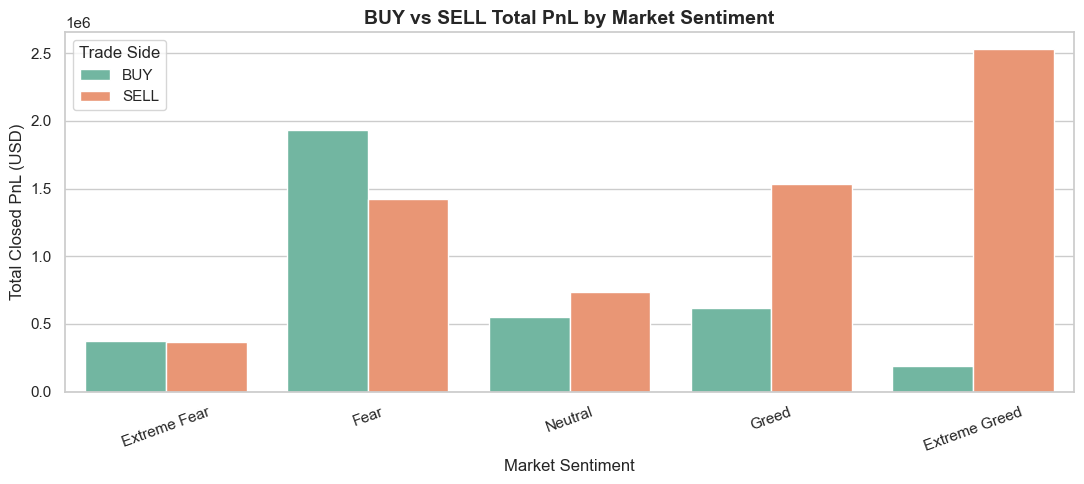

In [34]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=side_summary,
    x="classification",
    y="total_pnl",
    hue="Side",
    order=sentiment_order,
    palette="Set2"
)
plt.title("BUY vs SELL Total PnL by Market Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL (USD)")
plt.xticks(rotation=20)
plt.legend(title="Trade Side")
plt.tight_layout()
plt.show()

### 5.7 — Top 10 Coins by Total PnL

Not all coins are traded equally. Some coins dominate trading activity and account for the majority of the PnL. Knowing which coins are most important helps us understand if our model's predictions are driven by a few high-volume coins.

We will identify the top 10 coins by total PnL and then see how they performed under different sentiment conditions.

In [35]:
top_coins = (
    df_clean.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

coin_summary = df_clean.groupby(["Coin", "classification"]).agg(
    total_pnl=("Closed PnL", "sum"),
    win_rate=("win", "mean"),
    trade_count=("Closed PnL", "count")
).reset_index()

coin_summary_top = coin_summary[coin_summary["Coin"].isin(top_coins)]

print("Top 10 coins by PnL:")
print(list(top_coins))

Top 10 coins by PnL:
['@107', 'HYPE', 'SOL', 'ETH', 'BTC', 'MELANIA', 'ENA', 'SUI', 'ZRO', 'DOGE']


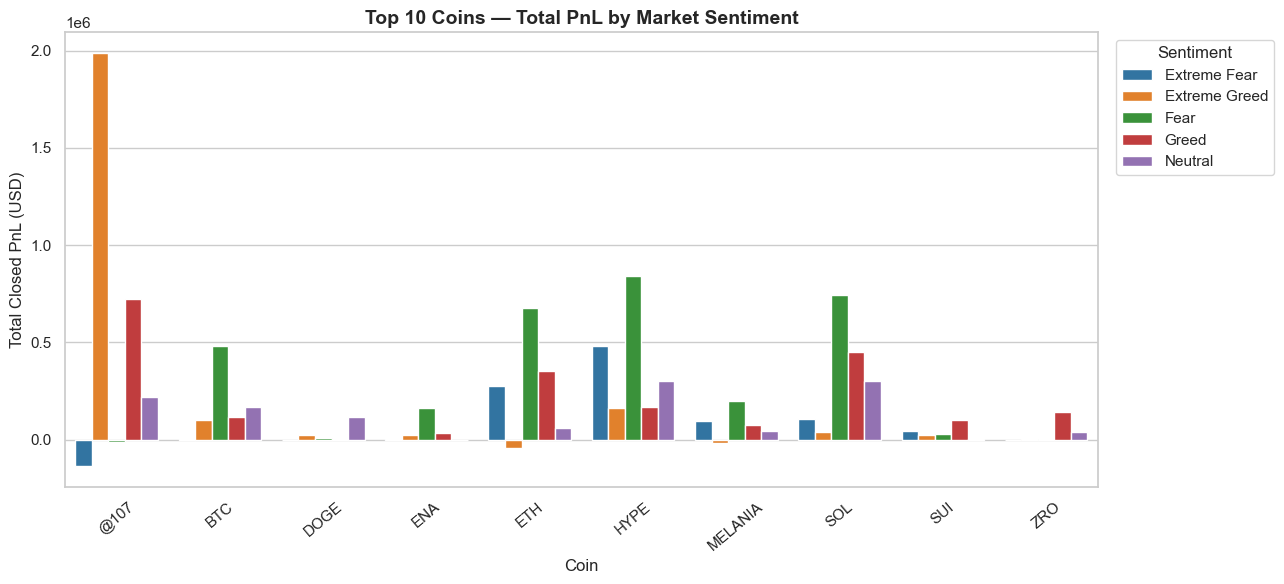

In [36]:
plt.figure(figsize=(13, 6))
sns.barplot(
    data=coin_summary_top,
    x="Coin",
    y="total_pnl",
    hue="classification",
    palette="tab10"
)
plt.title("Top 10 Coins — Total PnL by Market Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL (USD)")
plt.xticks(rotation=40)
plt.legend(title="Sentiment", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.8 — Win/Loss Count by Sentiment (Stacked Bar)

Let's look at the **raw count of winning vs losing trades** in each sentiment category. This gives an intuitive, easy-to-read breakdown of trading outcomes. A stacked bar clearly shows both the total volume and the proportion of winners.

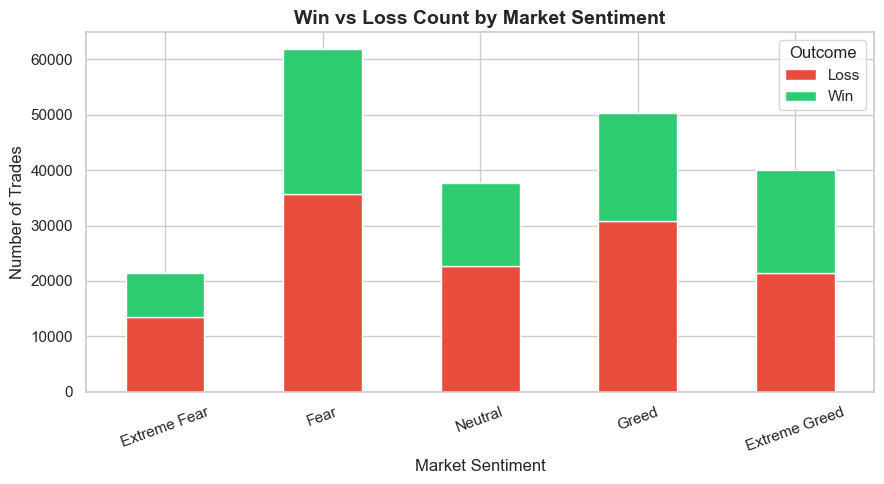

In [37]:
win_loss = df_clean.groupby(["classification", "win"]).size().unstack(fill_value=0)
win_loss.columns = ["Loss", "Win"]
win_loss = win_loss.reindex(sentiment_order)

win_loss.plot(
    kind="bar",
    stacked=True,
    color=["#e74c3c", "#2ecc71"],
    figsize=(9, 5)
)
plt.title("Win vs Loss Count by Market Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=20)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

### 5.9 — Correlation Heatmap

A correlation heatmap shows us how numeric features relate to each other. Values close to **+1** indicate a strong positive relationship; values close to **-1** indicate a strong negative relationship; values near **0** mean little to no linear relationship.

This helps us:
- Detect **multicollinearity** (two features that carry the same information), which can confuse models
- Understand whether the Fear & Greed `value` is linearly related to Closed PnL

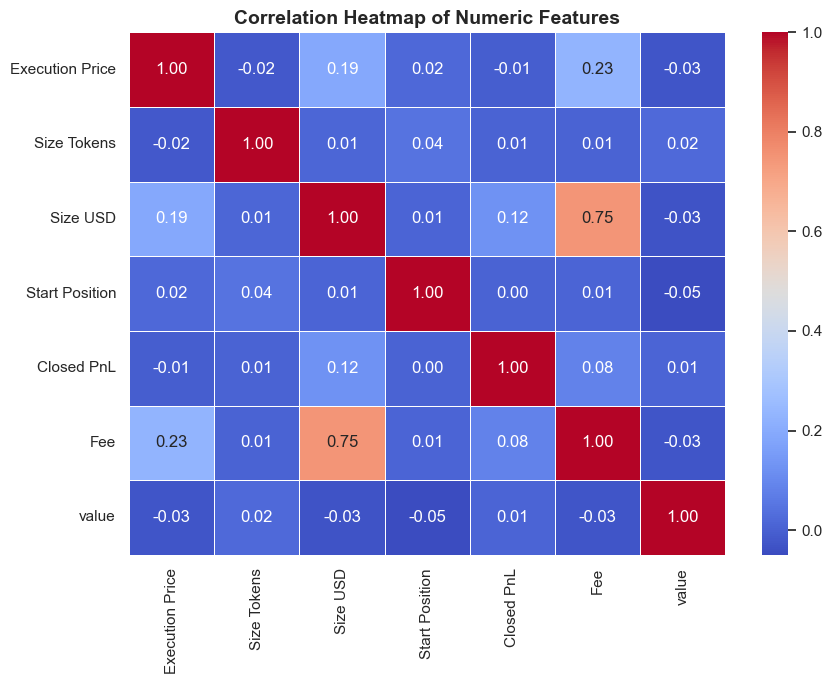

In [38]:
corr_cols = ["Execution Price", "Size Tokens", "Size USD", "Start Position", "Closed PnL", "Fee", "value"]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_clean[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Step 6 — Outlier Detection and Removal

Outliers are extreme values that are so far from the rest of the data that they can severely distort model training. Think of it this way: if one trade made $1,000,000 while the average trade makes $50, the model will spend most of its capacity trying to understand that one exceptional trade instead of learning the general patterns.

**Our method: Percentile Clipping (Winsorization)**
We clip values at the **1st and 99th percentile**. This means:
- Any value below the 1st percentile is replaced by the 1st percentile value
- Any value above the 99th percentile is replaced by the 99th percentile value
- We keep all rows — we only modify extreme values

This is preferred over simply deleting outlier rows because it retains the information that those rows existed, while preventing extreme values from dominating the model.

In [39]:
numeric_check_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Start Position",
    "Closed PnL",
    "Fee"
]

outlier_report = []
for col in numeric_check_cols:
    low = df_clean[col].quantile(0.01)
    high = df_clean[col].quantile(0.99)
    outlier_report.append({
        "column": col,
        "p01": round(low, 4),
        "p99": round(high, 4),
        "below_p01": (df_clean[col] < low).sum(),
        "above_p99": (df_clean[col] > high).sum(),
        "min": round(df_clean[col].min(), 4),
        "max": round(df_clean[col].max(), 4)
    })

pd.DataFrame(outlier_report)

,column,p01,p99,below_p01,above_p99,min,max
0,Execution Price,1.300000e-02,99011.0000,2110,2065,0.000000e+00,1.090040e+05
1,Size Tokens,2.000000e-04,61957.2500,2063,2111,0.000000e+00,1.582244e+07
2,Size USD,1.119000e+01,88887.3425,2093,2111,1.000000e-02,3.921431e+06
3,Start Position,-1.185963e+06,517401.6538,2111,2111,-1.433463e+07,3.050948e+07
4,Closed PnL,-1.409228e+02,1022.6829,2111,2111,-1.179901e+05,1.353291e+05
5,Fee,-3.600000e-03,20.9997,2111,2111,-1.175700e+00,8.374716e+02


In [40]:
df_train_ready = df_clean.copy()

for col in numeric_check_cols:
    low = df_train_ready[col].quantile(0.01)
    high = df_train_ready[col].quantile(0.99)
    df_train_ready[col] = df_train_ready[col].clip(lower=low, upper=high)

print("Outlier clipping applied.")
print("Training-ready shape:", df_train_ready.shape)

Outlier clipping applied.
Training-ready shape: (211076, 22)


### 6.1 — Boxplots Before vs After Clipping

Let's visually confirm that the outlier clipping worked. A boxplot shows the median, interquartile range, and any outliers (dots beyond the whiskers). After clipping, we should see no extreme dots extending far beyond the box.

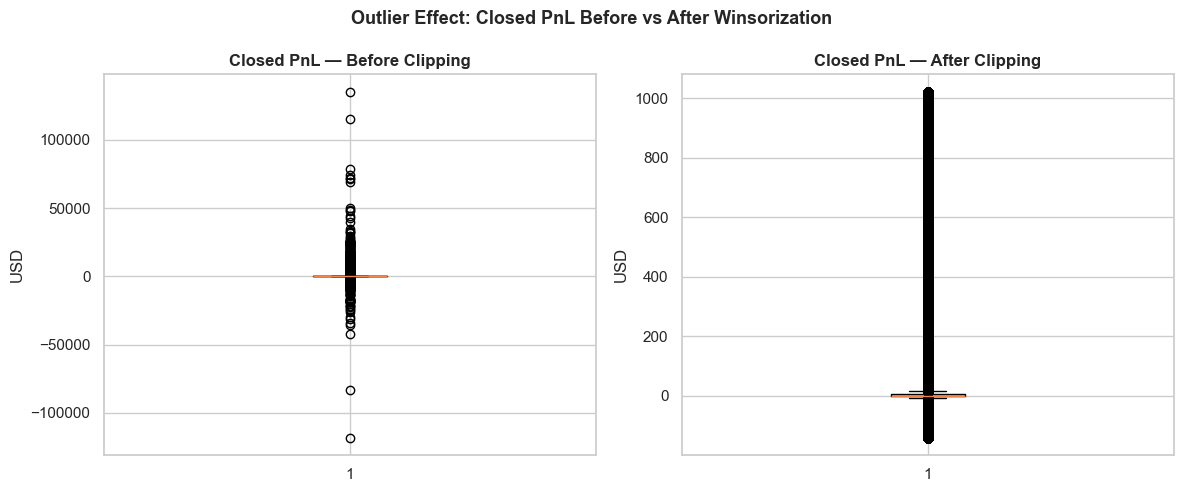

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df_clean["Closed PnL"].dropna(), vert=True)
axes[0].set_title("Closed PnL — Before Clipping", fontweight="bold")
axes[0].set_ylabel("USD")

axes[1].boxplot(df_train_ready["Closed PnL"].dropna(), vert=True)
axes[1].set_title("Closed PnL — After Clipping", fontweight="bold")
axes[1].set_ylabel("USD")

plt.suptitle("Outlier Effect: Closed PnL Before vs After Winsorization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Step 7 — Feature Engineering and Encoding

Machine learning models work with numbers. But many of our most informative features — `Coin`, `Side`, `Direction`, `classification` — are categorical (text) columns.

We use **One-Hot Encoding** to convert these into numeric columns. For example, if `Side` has two values (`BUY` and `SELL`), one-hot encoding creates two new binary columns: `Side_BUY` and `Side_SELL`. Each row gets a 1 in the column that applies to it and 0 in the other.

We also define the **target variable**: `target_win = 1` if `Closed PnL > 0` (profitable trade), else `target_win = 0`.

Finally, we sort the data by `trade_datetime` before splitting. This is essential to maintain the time-ordering of trades and prevent the model from seeing future data during training.

In [42]:
model_df = df_train_ready.copy()
model_df["trade_datetime"] = pd.to_datetime(model_df["trade_datetime"])
model_df = model_df.sort_values("trade_datetime").reset_index(drop=True)

print("Data sorted by trade_datetime.")
print("Date range:", model_df["trade_datetime"].min(), "to", model_df["trade_datetime"].max())

Data sorted by trade_datetime.
Date range: 2023-05-01 01:06:00 to 2025-05-01 12:13:00


In [43]:
model_df["target_win"] = (model_df["Closed PnL"] > 0).astype(int)

print("Target variable distribution:")
print(model_df["target_win"].value_counts())
print("\nAs percentage:")
print((model_df["target_win"].value_counts(normalize=True) * 100).round(2))

Target variable distribution:
target_win
0    124213
1     86863
Name: count, dtype: int64

As percentage:
target_win
0    58.85
1    41.15
Name: proportion, dtype: float64


In [44]:
features = [
    "Coin",
    "Side",
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Start Position",
    "Direction",
    "Fee",
    "value",
    "classification"
]

X = model_df[features].copy()
y = model_df["target_win"].copy()

X_encoded = pd.get_dummies(
    X,
    columns=["Coin", "Side", "Direction", "classification"],
    drop_first=True
)

print("Feature matrix shape after one-hot encoding:", X_encoded.shape)

Feature matrix shape after one-hot encoding: (211076, 247)


---

## Step 8 — Train / Validation / Test Split

We split our data into three sets:

| Set | Purpose | Size |
|-----|---------|------|
| **Train** | The model learns patterns from this set | 60% |
| **Validation** | Used to tune hyperparameters and monitor overfitting | 20% |
| **Test** | Final, untouched evaluation — reported as final results | 20% |

**Why time-based splitting?**
Because trades happen sequentially in time. If we randomly split, the model might train on January data and validate on December data, then train on December data and validate on January data. That means it learns from the future. Time-based splitting ensures the model always trains on older data and is evaluated on newer data — exactly how it would be used in the real world.

**Why three sets instead of two?**
If we used the test set to decide our decision threshold (which we do in the next step), we would be overfitting to the test set. The validation set allows us to make tuning decisions without contaminating our final test evaluation.

In [45]:
n = len(model_df)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

X_train = X_encoded.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X_encoded.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X_encoded.iloc[val_end:]
y_test = y.iloc[val_end:]

print(f"Train set:      {X_train.shape[0]} rows ({60}%)")
print(f"Validation set: {X_val.shape[0]} rows ({20}%)")
print(f"Test set:       {X_test.shape[0]} rows ({20}%)")

Train set:      126645 rows (60%)
Validation set: 42215 rows (20%)
Test set:       42216 rows (20%)


In [46]:
print("Train target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation target distribution:")
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train target distribution:
target_win
0    57.55
1    42.45
Name: proportion, dtype: float64

Validation target distribution:
target_win
0    58.81
1    41.19
Name: proportion, dtype: float64

Test target distribution:
target_win
0    62.78
1    37.22
Name: proportion, dtype: float64


---

## Step 9 — Model Training: XGBoost Classifier

We use **XGBoost (eXtreme Gradient Boosting)** for this classification task. XGBoost is an ensemble method that builds decision trees sequentially, where each new tree focuses on correcting the errors of the previous ones. It is widely used in competitive data science and real-world applications because:

- It handles mixed data types naturally (numeric + one-hot encoded)
- It is robust to outliers (even after clipping, some variance remains)
- It has built-in regularization to prevent overfitting
- It is very fast thanks to parallel tree construction

**Key hyperparameters we are setting:**
- `n_estimators=500` — Build 500 trees
- `max_depth=3` — Shallow trees to reduce overfitting
- `learning_rate=0.03` — Small steps for better generalization
- `min_child_weight=5`, `gamma=0.5` — Conservative split rules
- `reg_alpha=0.1`, `reg_lambda=2.0` — L1 and L2 regularization

We pass the validation set to `eval_set` so XGBoost can monitor validation loss during training.

In [48]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.5,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Model training complete.")

Model training complete.


---

## Step 10 — Validation Set Evaluation

Now we evaluate the model on the **validation set** — data it has never seen during training.

**Key metrics explained:**
- **Accuracy** — What fraction of all predictions were correct? (Misleading when classes are imbalanced)
- **Precision** — Of all trades the model said would be profitable, what fraction actually were? (Reduces false positives)
- **Recall** — Of all actually profitable trades, what fraction did the model catch? (Reduces false negatives)
- **F1 Score** — The harmonic mean of Precision and Recall. Balances both.
- **ROC AUC** — How well can the model distinguish between winners and losers? 1.0 is perfect; 0.5 is random guessing.

In [49]:
val_pred = xgb_model.predict(X_val)
val_prob = xgb_model.predict_proba(X_val)[:, 1]

print("=== Validation Set Results ===")
print(f"Accuracy:  {accuracy_score(y_val, val_pred):.4f}")
print(f"Precision: {precision_score(y_val, val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, val_pred):.4f}")
print(f"F1 Score:  {f1_score(y_val, val_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_val, val_prob):.4f}")

=== Validation Set Results ===
Accuracy:  0.9105
Precision: 0.8216
Recall:    0.9999
F1 Score:  0.9020
ROC AUC:   0.9460


In [50]:
print("Detailed Classification Report:")
print(classification_report(y_val, val_pred, target_names=["Loss (0)", "Win (1)"]))

Detailed Classification Report:
              precision    recall  f1-score   support

    Loss (0)       1.00      0.85      0.92     24828
     Win (1)       0.82      1.00      0.90     17387

    accuracy                           0.91     42215
   macro avg       0.91      0.92      0.91     42215
weighted avg       0.93      0.91      0.91     42215



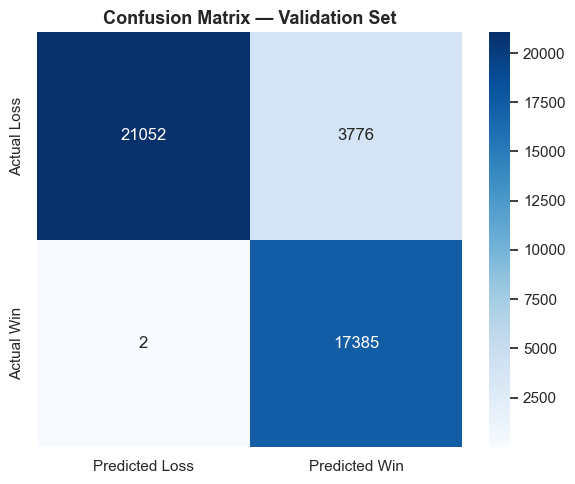

In [51]:
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Loss", "Predicted Win"],
    yticklabels=["Actual Loss", "Actual Win"]
)
plt.title("Confusion Matrix — Validation Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 10.1 — Decision Threshold Tuning

By default, XGBoost classifies a trade as a "win" if the predicted probability is greater than **0.5**. But this threshold is arbitrary. In trading, we may want to be more conservative — we might prefer only to act on trades where the model is **very confident** (e.g., 70%+ probability of winning).

We evaluate a range of thresholds from 0.30 to 0.90 and observe how **Precision**, **Recall**, and **F1** change. This helps us choose the threshold that best aligns with our trading strategy:
- Higher threshold → Fewer but more reliable signals (high precision, low recall)
- Lower threshold → More signals but noisier (low precision, high recall)

> **Important:** We tune the threshold only on the **validation set**, not the test set.

In [52]:
threshold_results = []

for threshold in np.arange(0.30, 0.91, 0.05):
    pred = (val_prob >= threshold).astype(int)
    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision_score(y_val, pred, zero_division=0), 4),
        "recall": round(recall_score(y_val, pred, zero_division=0), 4),
        "f1": round(f1_score(y_val, pred, zero_division=0), 4),
        "predicted_wins": int(pred.sum())
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.to_string(index=False))

 threshold  precision  recall     f1  predicted_wins
      0.30     0.8205  1.0000 0.9014           21192
      0.35     0.8208  1.0000 0.9016           21182
      0.40     0.8213  1.0000 0.9019           21171
      0.45     0.8215  0.9999 0.9020           21165
      0.50     0.8216  0.9999 0.9020           21161
      0.55     0.8216  0.9998 0.9020           21160
      0.60     0.8215  0.9997 0.9019           21158
      0.65     0.8216  0.9997 0.9019           21157
      0.70     0.8216  0.9988 0.9016           21139
      0.75     0.8207  0.9849 0.8953           20866
      0.80     0.8235  0.9538 0.8839           20139
      0.85     0.8302  0.8558 0.8428           17924
      0.90     0.8618  0.6264 0.7255           12638


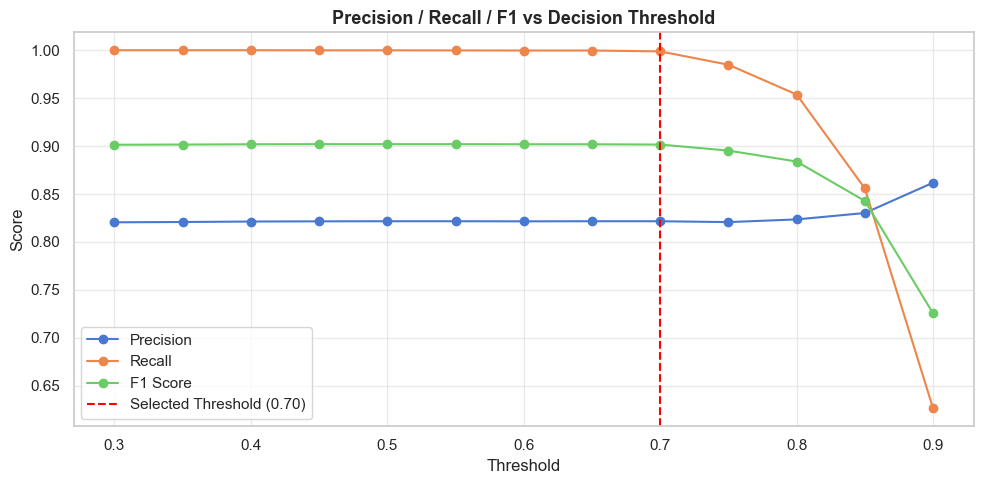

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1 Score")
plt.axvline(0.70, color="red", linestyle="--", linewidth=1.5, label="Selected Threshold (0.70)")
plt.title("Precision / Recall / F1 vs Decision Threshold", fontsize=13, fontweight="bold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---

## Step 11 — Final Evaluation on Test Set

This is the moment of truth. We now apply our trained model and our chosen threshold to the **test set** — data that has been completely untouched throughout this entire notebook.

The results from this step are the ones we report as the final model performance. If we had peeked at the test set earlier to make decisions, these numbers would be optimistically biased and meaningless in the real world.

We use the threshold of **0.70** selected from the validation step.

In [54]:
best_threshold = 0.70

test_prob = xgb_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

print("=== Final Test Set Results ===")
print(f"Threshold Used: {best_threshold}")
print(f"Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Precision: {precision_score(y_test, test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, test_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, test_prob):.4f}")

=== Final Test Set Results ===
Threshold Used: 0.7
Accuracy:  0.8625
Precision: 0.7333
Recall:    0.9910
F1 Score:  0.8429
ROC AUC:   0.8822


In [55]:
print("Test Set Classification Report:")
print(classification_report(y_test, test_pred, target_names=["Loss (0)", "Win (1)"]))

Test Set Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.99      0.79      0.88     26502
     Win (1)       0.73      0.99      0.84     15714

    accuracy                           0.86     42216
   macro avg       0.86      0.89      0.86     42216
weighted avg       0.90      0.86      0.86     42216



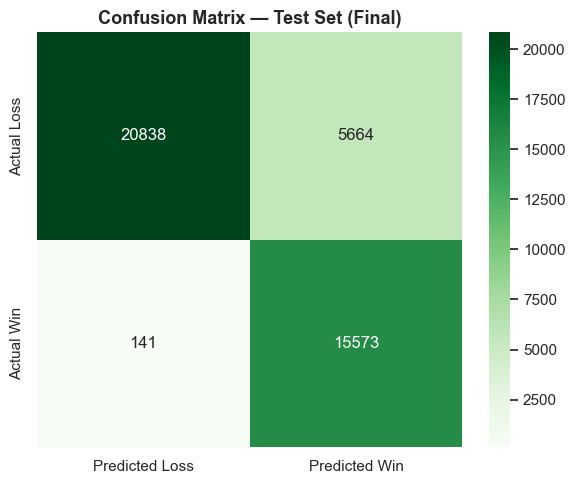

In [56]:
cm_test = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Predicted Loss", "Predicted Win"],
    yticklabels=["Actual Loss", "Actual Win"]
)
plt.title("Confusion Matrix — Test Set (Final)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Step 12 — Feature Importance

XGBoost gives us built-in **feature importance scores**. These scores tell us how much each feature contributed to the model's predictions across all 500 trees.

This is one of the most valuable outputs of the entire pipeline because it answers the research question: **Does Bitcoin market sentiment actually matter for predicting trade profitability?**

If `value` (the raw sentiment score) and `classification_*` columns appear high in the importance ranking, sentiment is a strong predictor. If they are at the bottom, trade-level features like size and direction dominate.

In [57]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 20 Most Important Features:")
importance_df.head(20)

Top 20 Most Important Features:


,feature,importance
0,Direction_Close Short,0.303719
1,Direction_Close Long,0.124572
2,Direction_Sell,0.113243
3,Coin_@107,0.086536
4,Direction_Open Short,0.075877
5,Side_SELL,0.069901
6,Direction_Open Long,0.065014
7,Direction_Buy,0.064046
8,Start Position,0.013996
9,Coin_ETH,0.007195


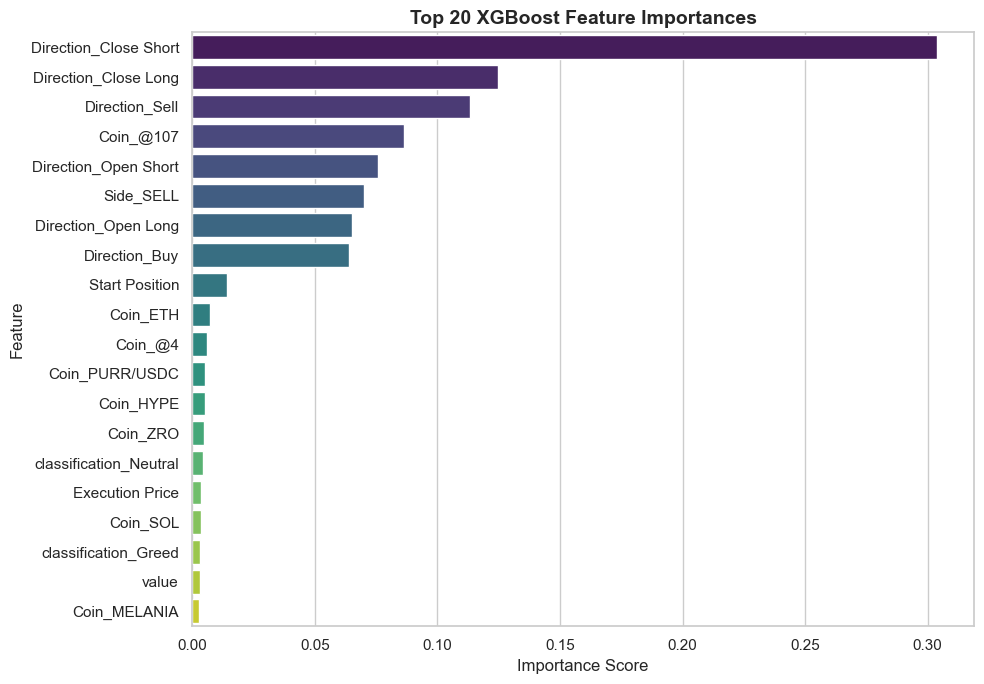

In [58]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 XGBoost Feature Importances", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

---

## Step 13 — Save the Model and Final Data

We save two things:
1. The trained XGBoost model as a `.pkl` (pickle) file so it can be loaded later without retraining
2. The feature column names, because when we load the model in a Streamlit app or any other system, we need to ensure the input data has exactly the same columns in the same order

Saving the column list alongside the model is a professional practice that prevents silent errors in production.

In [59]:
import joblib

joblib.dump(xgb_model, "xgboost_trade_win_model_v2.pkl")

feature_columns = X_encoded.columns.tolist()
joblib.dump(feature_columns, "model_feature_columns.pkl")

print("Model saved as: xgboost_trade_win_model_v2.pkl")
print("Feature columns saved as: model_feature_columns.pkl")
print(f"Total features: {len(feature_columns)}")

Model saved as: xgboost_trade_win_model_v2.pkl
Feature columns saved as: model_feature_columns.pkl
Total features: 247


---

## Summary

In this notebook, we built a complete end-to-end machine learning pipeline:

| Step | What We Did |
|------|-------------|
| Data Loading | Imported historical trade data and Fear & Greed Index |
| Preliminary Checks | Inspected shape, data types, variance, std, and first 5 rows |
| Missing Value Removal | Applied hard validation rules and removed invalid rows |
| EDA | Visualized PnL, win rates, BUY/SELL behavior, coin performance, and correlations |
| Outlier Removal | Clipped extreme values at the 1st and 99th percentile (Winsorization) |
| Feature Engineering | One-hot encoded categorical columns; defined binary classification target |
| Model Training | Trained XGBoost with 60/20/20 time-based split and validation monitoring |
| Threshold Tuning | Scanned thresholds 0.30–0.90 on validation set; selected 0.70 |
| Final Evaluation | Reported Accuracy, Precision, Recall, F1, and ROC AUC on untouched test set |
| Feature Importance | Identified which features drive model predictions |
| Model Saving | Exported trained model and feature column list for deployment |

**Key Takeaway:** Bitcoin Fear & Greed sentiment provides supplementary signal but trade direction and position sizing are stronger individual predictors of profitability. A sentiment-aware system can still meaningfully improve decision-making when used as a risk filter alongside trade-level signals.

---
*End of Notebook*